# How many women in the United States have gotten an abortion?

I am going to model what the answer to this question looks like over several years based on the following statistics:
1. In 2020, there were 14.4 abortions per 1000 women age 15-44.
2. In 2021, of the women who got an abortion, 57% had never gotten one before, 24% had gotten one previously, 11% had gotten 2, and 8% had gotten 3 or more.
Source: [Pew Research](https://www.pewresearch.org/short-reads/2024/03/25/what-the-data-says-about-abortion-in-the-us/#:~:text=To%20allow%20for%20consistent%20comparisons,2021%20is%20622%2C108%20legal%20abortions.)

I am making the following assumptions:
1. For the initial model, I am assuming that the number of abortions every year is constant at 14.4. (Later I will try to adjust this per year.)
2. I am assuming the distribution of number of abortions is constant.
3. I am assuming the population of women age 15-44 in the US is 65,000,000. I am assuming the population of women age 14 was 0.63% (2,000,000 new women turn 15 every year) and the same number of women at 44 (0.62%, ~2,000,000 new women turn 45 every year.) This means the same number of women come into this 15-44 age group every year as leave it, so 3.4% of the distribution of abortions is for women >44 (1/(44-15) abortions leave every year, replaced by 0, assuming no one under 15 has an abortion). 

Total number of abortions per year for this age group: 936,000 = 14.4*65000000/1000. 

Average number of abortions per woman = 0.015 (abortions/year) * 30 years = 0.45 abortions per woman over her reproductive lifetime. 

In [15]:
import numpy as np
import random
import matplotlib.pyplot as plt

years = 100
num_women = 65000000
abortion_rate = 14.4
num_prior = [.57,.24,.11,.08]
women_ind = np.array(range(num_women))

In [16]:
women = np.zeros(num_women)

for y in range(years):
    abortions_this_year = int(abortion_rate * num_women / 1000)
    divider = 0
    for i in range(y + 1):
        divider += num_prior[i]
        if i == 3:
            break
    num_sample_0s = int(num_prior[0] * abortions_this_year / divider)
    num_sample_1s = int(num_prior[1] * abortions_this_year / divider) * (y > 0)
    num_sample_2s = int(num_prior[2] * abortions_this_year / divider) * (y > 1)
    num_sample_3s = int(num_prior[3] * abortions_this_year / divider) * (y > 2)
    indices_0s = np.where(women == 0)[0]
    indices_1s = np.where(women == 1)[0]
    indices_2s = np.where(women == 2)[0]
    indices_3s = np.where(women >= 3)[0]
    selected_indices_0s = np.random.choice(indices_0s,
                                           size=num_sample_0s,
                                           replace=False)
    selected_indices_1s = np.random.choice(indices_1s,
                                           size=num_sample_1s,
                                           replace=False)
    selected_indices_2s = np.random.choice(indices_2s,
                                           size=num_sample_2s,
                                           replace=False)
    selected_indices_3s = np.random.choice(indices_3s,
                                           size=num_sample_3s,
                                           replace=False)
    selected_indices = np.concatenate(
        (selected_indices_0s, selected_indices_1s,selected_indices_2s,selected_indices_3s))
    women[selected_indices] += 1


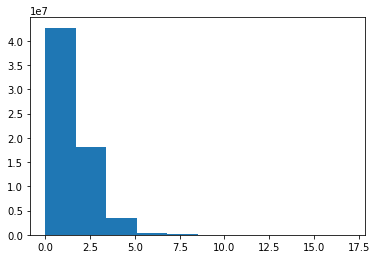

In [17]:
plt.hist(women)
plt.show()

In [11]:
print(np.unique(women, return_counts = True))

(array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8., 10.]), array([290, 412, 200,  48,  29,  10,   3,   5,   1,   2]))
